                                                               ARIMA                                                                           

## ARIMA

ARIMA (Autoregressive Integrated Moving Average) model is used for forecasting time series data. It combines three components: autoregression (AR), differencing (I) and moving averages (MA). These components allow the model to capture patterns such as trends and seasonality, helping to predict future values based on historical data. It combines three key components to model data:

## 1. Autoregression (AR):

The autoregressive part (AR) of an ARIMA model is represented by the parameter p. It signifies the dependence of the current observation on its previous values. Mathematically, an AR(p) model can be represented as:

Y_t = c + φ_1 * Y_{t-1} + φ_2 * Y_{t-2} + ... + φ_p * Y_{t-p} + ε_t

Where:
- Y_t is the current value of the time series at time t.
- c is a constant term.
- φ_1, φ_2, ..., φ_p are the coefficients of the autoregressive terms.
- ε_t is the error term at time t.

## 2. Differencing (I):

The differencing part of ARIMA is represented by the parameter d. It involves transforming a non stationary time series into a stationary one by differencing consecutive observations. We can apply the differencing operation multiple times until stationarity is achieved. The formula for differencing is:straightforward

Y'_t = Y_t - Y_{t-1}

Where:
- Y'_t is the differenced value at time t.
- Y_t is the original value at time t.
- Y_{t-1} is the value at time t-1. This process can be repeated d times to achieve stationarity.

## 3. Moving Average (MA):

The moving average part (MA) of an ARIMA model is represented by the parameter q. It indicates the dependence of the current observation on the previous forecast errors. Mathematically, an MA(q) model can be represented as:

Y_t = c + ε_t + θ_1 * ε_{t-1} + θ_2 * ε_{t-2} + ... + θ_q * ε_{t-q}

Where:
- Y_t is the current value of the time series at time t.
- c is a constant term.
- ε_t is the error term at time t.
- θ_1, θ_2, ..., θ_q are the coefficients of the moving average terms.
- ε_{t-1}, ε_{t-2}, ..., ε_{t-q} are the previous error terms.

## Working Principles

**Identifying Stationarity:** ARIMA models require the time series data to be stationary. Stationarity implies that the statistical properties of the time series like mean and variance remain constant over time.

**Parameter Estimation:** Estimating the parameters p, d and q involves analyzing the autocorrelation function (ACF) and partial autocorrelation function (PACF) plots of the time series data. ACF helps determine the MA order (q) while PACF aids in determining the AR order (p).

**Model Fitting:** Once the parameters are determined the ARIMA model is fitted to the data. This involves minimizing the error often using methods like maximum likelihood estimation to obtain the most suitable coefficients for the autoregressive and moving average terms.
Forecasting: After fitting the model it can be used to forecast future values by iterating over time.

## Model Parameters in ARIMA

- **p (AR order):** This parameter represents the number of lag observations included in the model. It indicates how many previous time steps are used to predict the current value.

- **d (Differencing order):** This parameter indicates the number of times the data needs to be differenced to achieve stationarity. Differencing helps to remove trends and seasonality from the data.

- **q (MA order):** This parameter represents the number of lagged forecast errors in the prediction equation. It indicates how many previous error terms are used to predict the current value.

## Implementation of ARIMA

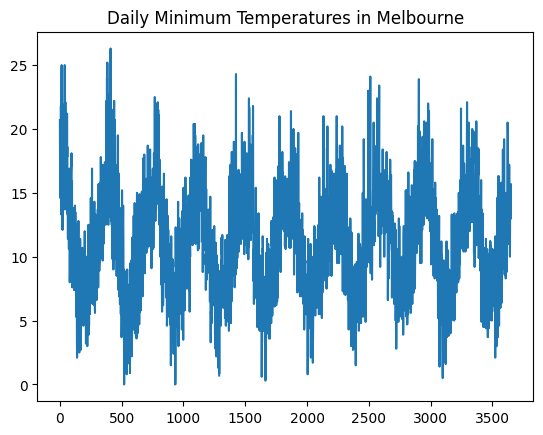

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
import itertools

warnings.filterwarnings('ignore')

data = pd.read_csv('https://raw.githubusercontent.com/itsluckysharma01/Datasets/refs/heads/main/daily-min-temperatures.csv')
data['Temp'] = pd.to_numeric(data['Temp'], errors='coerce')
ts = data['Temp']

ts.plot(title='Daily Minimum Temperatures in Melbourne')
plt.show()

ADF Statistic: -4.444653
p-value: 0.000247
Series is stationary; no differencing needed.


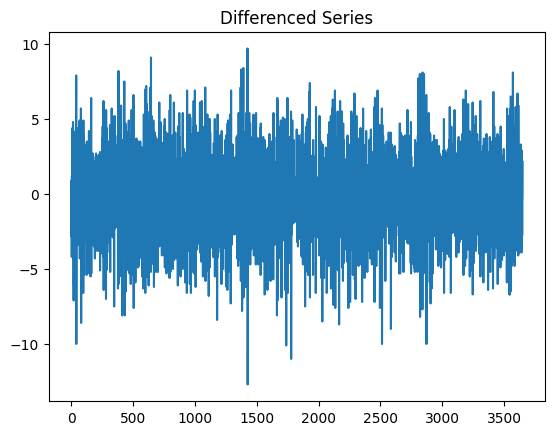

ADF Statistic (differenced): -21.079000
p-value (differenced): 0.000000


In [2]:
ts = ts.dropna()
result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

if result[1] > 0.05:
    print("Series is non stationary; differencing is needed.")
else:
    print("Series is stationary; no differencing needed.")


ts_diff = ts.diff().dropna()

ts_diff.plot(title='Differenced Series')
plt.show()

result_diff = adfuller(ts_diff)
print('ADF Statistic (differenced): %f' % result_diff[0])
print('p-value (differenced): %f' % result_diff[1])

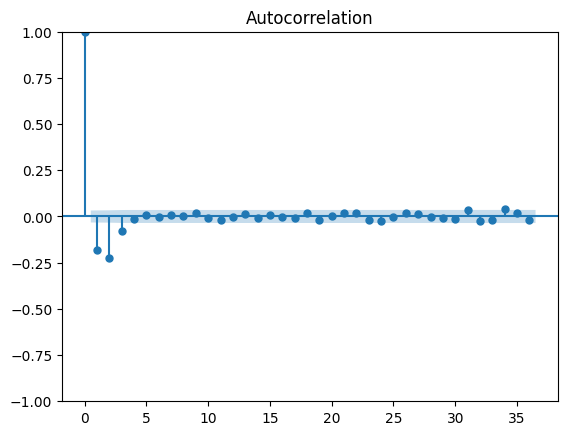

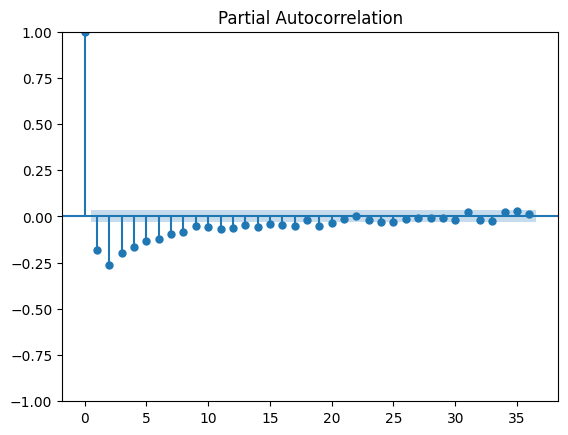

In [3]:
plot_acf(ts_diff)
plt.show()

plot_pacf(ts_diff)
plt.show()

## ARIMA Model Selection Using Grid Search

In [4]:
p = range(0, 4)
d = range(0, 3)
q = range(0, 4)
pdq = list(itertools.product(p, d, q))

best_aic = np.inf
best_order = None
best_model = None

for order in pdq:
    try:
        model = ARIMA(ts, order=order)
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
            best_model = results
    except:
        continue

print(f'Best ARIMA order: {best_order} with AIC: {best_aic}')

Best ARIMA order: (3, 0, 1) with AIC: 16760.85768083491


In [5]:
final_model = ARIMA(ts, order=best_order)
results = final_model.fit()

forecast_values = results.forecast(steps=10)

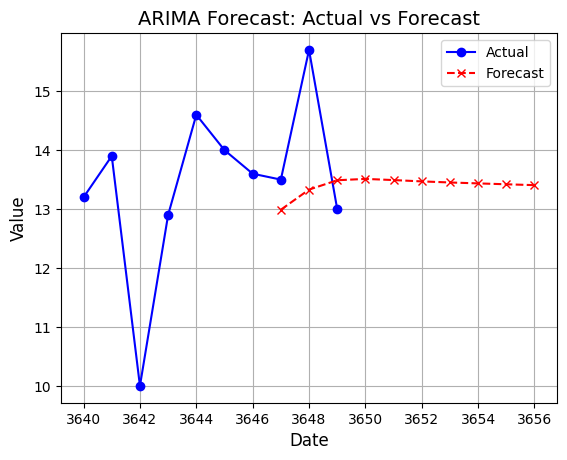

In [6]:
plt.plot(ts[-10:].index, ts[-10:], label='Actual', color='blue', linestyle='-', marker='o')
plt.plot(forecast_values.index, forecast_values, label='Forecast', color='red', linestyle='--', marker='x')

plt.title('ARIMA Forecast: Actual vs Forecast', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

                                                              SARIMA (Seasonal Autoregressive Integrated Moving Average)
                                                       

## SARIMA (Seasonal Autoregressive Integrated Moving Average)


SARIMA or Seasonal Autoregressive Integrated Moving Average is an extension of the traditional ARIMA model, specifically designed for time series data with seasonal patterns. While ARIMA is great for non-seasonal data, SARIMA introduces seasonal components to handle periodic fluctuations and provides better forecasting capabilities for seasonal data.

## Understanding the Components of SARIMA

SARIMA consists of several components that help capture both short-term and long-term dependencies within a time series:

**Seasonal Component:** Represents the repeating patterns or cycles in the data at regular intervals like yearly, monthly, daily, etc. This allows SARIMA to model seasonality effectively.
**Autoregressive (AR) Component:** Models the relationship between current and past observations. It captures the autocorrelation of the data over time.
**Integrated (I) Component:** Addresses non-stationarity by differencing the data to make it stationary which is crucial for time series analysis.
**Moving Average (MA) Component:** Models the relationship between current observations and past residual errors. It helps in capturing short-term fluctuations.

## SARIMA Notation

SARIMA models are typically denoted as SARIMA(p, d, q)(P, D, Q)m where:
- p: Order of the autoregressive part (AR)
- d: Degree of differencing (I)
- q: Order of the moving average part (MA)
- P: Order of the seasonal autoregressive part (SAR)
- D: Degree of seasonal differencing (SI)
- Q: Order of the seasonal moving average part (SMA)
- m: Length of the seasonal cycle (e.g., 12 for monthly data)   

Before applying SARIMA, seasonal differencing is often required to make the data stationary. This process involves subtracting the current observation from one that corresponds to the same season in the previous cycle. Seasonal differencing helps remove the seasonal pattern from the data, enabling more accurate forecasting.

## Understanding Mathematical Representation of SARIMA

The mathematical representation of a SARIMA model can be expressed as follows:  
Y_t = c + φ_1 * Y_{t-1} + φ_2 * Y_{t-2} + ... + φ_p * Y_{t-p} + θ_1 * ε_{t-1} + θ_2 * ε_{t-2} + ... + θ_q * ε_{t-q} + Φ_1 * Y_{t-m} + Φ_2 * Y_{t-2m} + ... + Φ_P * Y_{t-Pm} + Θ_1 * ε_{t-m} + Θ_2 * ε_{t-2m} + ... + Θ_Q * ε_{t-Qm} + ε_t

Where:
- Y_t is the current value of the time series at time t.        
- c is a constant term.
- φ_1, φ_2, ..., φ_p are the coefficients of the autoregressive terms.
- θ_1, θ_2, ..., θ_q are the coefficients of the moving average terms.
- Φ_1, Φ_2, ..., Φ_P are the coefficients of the seasonal autoregressive terms.
- Θ_1, Θ_2, ..., Θ_Q are the coefficients of the seasonal moving average terms.
- ε_t is the error term at time t.

## Exponential Smoothing for Time Series Forecasting


Exponential smoothing is a popular time series forecasting method known for its simplicity and accuracy in predicting future trends based on historical data. It assumes that future patterns will be similar to recent past data and focuses on learning the average demand level over time.

It gives more weight to the most recent observations and reduces exponentially as the distance from the observations rises with the premise that the future will be similar to the recent past. The word "exponential smoothing" refers to the fact that each demand observation is assigned an exponentially diminishing weight.

* This technique captures the general pattern and can be expanded to include trends and seasonal variations, allowing for precise time series forecasts using past data.

* This method gives a bit of erroneous long-term forecasts.

* It works well with the technique of smoothing when the parameters of the time series change gradually over time.

## Types of Exponential Smoothing

There are several types of exponential smoothing methods, each suited for different patterns in time series data:
- **Simple Exponential Smoothing (SES):** This method is suitable for time series data without trends or seasonality. It uses a single smoothing parameter to forecast future values based on the weighted average of past observations.
- **Holt’s Linear Trend Method:** This method extends SES by incorporating a trend component. It is suitable for time series data with a linear trend but no seasonality.
- **Holt-Winters Seasonal Method:** This method further extends Holt’s method by adding a seasonal component. It is suitable for time series data with both trend and seasonality.
